In [2]:
import pandas as pd
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]


In [3]:
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.head())


   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


# Gaussian Naive Bayes (continuous features)

In [6]:
# Feature Engineering: Extract numerical features
df['text_length'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
df['num_digits'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))

# Define features and target
X = df[['text_length', 'num_words', 'num_digits']]
y = df['label']
from sklearn.model_selection import train_test_split
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)


In [9]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gnb).ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)


TP: 140
TN: 953
FP: 12
FN: 10


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_gnb)
print("Accuracy:", accuracy)


Accuracy: 0.9802690582959641


# Multinomial Naive Byes (For Text Data)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text data into word count vectors
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(df['text'])


In [12]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split

# Convert counts to TF-IDF representation
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_counts)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42
)


In [13]:
from sklearn.naive_bayes import MultinomialNB

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_mnb)
print("Accuracy:", accuracy)


Accuracy: 0.968609865470852


In [17]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mnb).ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)


TP: 115
TN: 965
FP: 0
FN: 35


# 3.Bernouli Naive Bayes (BNB) (For binary Features)

In [32]:
# Convert text into binary presence/absence of important words
important_words = ['free', 'win', 'offer', 'money', 'urgent']

for word in important_words:
    df[word] = df['text'].apply(lambda x: 1 if word in x.lower() else 0)



In [33]:
X = df[important_words]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_bnb)
print("Accuracy:", accuracy)


Accuracy: 0.895067264573991


In [35]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bnb).ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)


TP: 69
TN: 929
FP: 36
FN: 81


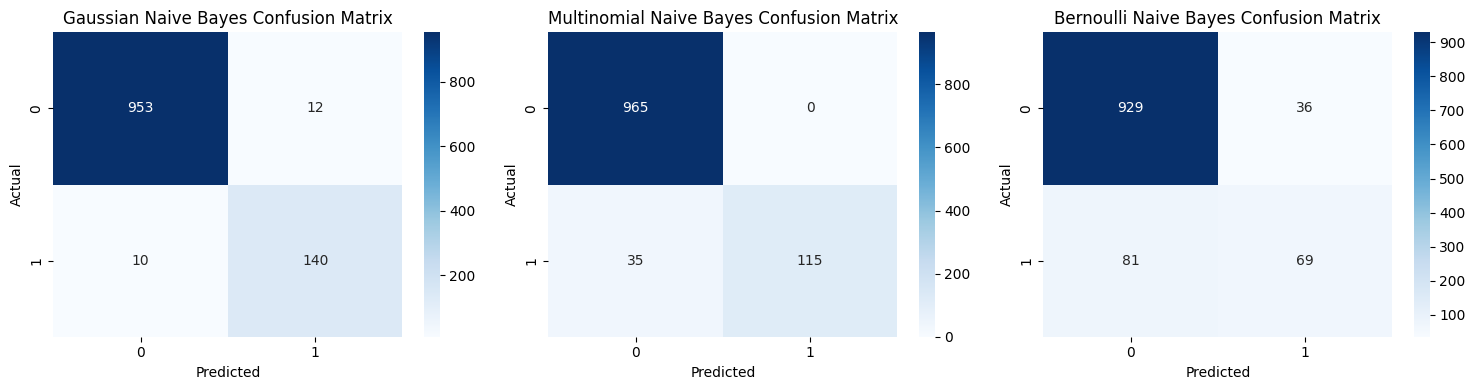

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

# Plot
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues')
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 3)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues')
plt.title("Bernoulli Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


*** Load the dataset and explore the message content and labels. ***
Identify how many messages belong to each category.
Build a probabilistic classification model that can learn patterns from word occurrences.
Train the model using historical message data.
Predict whether unseen messages are:
Suspicious
Not suspicious
Test the system using custom user-entered messages.
Evaluate the model using appropriate classification metrics.
Analyze the following:
How many suspicious messages were correctly identified?
How many genuine messages were incorrectly flagged?
 

In [37]:
df['label'].value_counts()


label
0    4825
1     747
Name: count, dtype: int64

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split


In [39]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['label']


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [41]:
y_pred = model.predict(X_test)


In [42]:
def predict_message(msg):
    msg_vec = vectorizer.transform([msg])
    pred = model.predict(msg_vec)[0]
    return "Suspicious" if pred == 1 else "Not Suspicious"

predict_message("Congratulations! You won ₹5000 cash")


'Suspicious'

In [43]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9802690582959641
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [44]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Correctly identified suspicious messages (TP):", tp)
print("Genuine messages incorrectly flagged (FP):", fp)


Correctly identified suspicious messages (TP): 139
Genuine messages incorrectly flagged (FP): 11
